In [1]:
import numpy as np 
import matplotlib.pyplot as plt
from scipy.sparse.linalg import eigsh
from scipy.linalg import norm
import pandas as pd

In [6]:
import sys
from pathlib import Path

# add parent directory to Python path
parent_dir = Path.cwd().parent
sys.path.append(str(parent_dir))

from dgp import generate_gaussian_data
from methods import solve_independent, aggregate_results, solve_dependent
from metrics import rv_coefficient, mse, relative_frobenius_norm
from plot_functions import plot_grid, plot_with_bands

In [7]:
rng = np.random.default_rng(1)
n = 2000
k = 2
edge_var = 1
sigma = 0

A, B, Z, X = generate_gaussian_data(n, k, sigma, edge_var=edge_var, rng=rng)

Zhat, evals_A = solve_independent(A, k=k)
Xhat, evals_B = solve_independent(B, k=k)
Zhat = Zhat[-1]
Xhat = Xhat[-1]

rv_coefficient(A, B), rv_coefficient(Zhat, Xhat), rv_coefficient(Z, X)

(np.float64(0.002355017558724935),
 np.float64(0.00183762500216916),
 np.float64(0.0018267051735628879))

#### Consistencty under independence

In [18]:
import pandas as pd
import itertools    

def simulation(nsim, n, k, sigma, edge_var, dgp, metric, rng, solver):
    if not isinstance(dgp, list):
        dgp = [dgp]
    if not isinstance(sigma, list):
        sigma = [sigma]
    if not isinstance(edge_var, list):
        edge_var = [edge_var]
    if not isinstance(n, list):
        n = [n]
    if not isinstance(k, list):
        k = [k]

    factorial_design = list(itertools.product(n, k, sigma, edge_var, dgp))
    out = []
    
    for i in range(nsim):
        for scenario in factorial_design:
            n, k, sigma, edge_var, dgp = scenario
            A, B, Z, X = dgp(n, k, sigma, edge_var=edge_var, rng=rng)
            true_M = np.block([[Z@Z.T, X@Z.T], [Z@X.T, X@X.T]])
            Zhat, evals_A = solver(A, k=k)
            Xhat, evals_B = solver(B, k=k)
            Zhat = Zhat[-1]
            Xhat = Xhat[-1]
            estimated_M = np.block([[Zhat@Zhat.T, Xhat@Zhat.T], [Zhat@Xhat.T, Xhat@Xhat.T]])
            err_M = metric(estimated_M, true_M)
            err_X = metric(Xhat@Xhat.T, X@X.T)
            err_Z = metric(Zhat@Zhat.T, Z@Z.T)
            out.append({'n': n, 'k': k, 'sigma': sigma, 'edge_var': edge_var, 'err_M': err_M, 'err_X': err_X, 'err_Z': err_Z})
    return pd.DataFrame(out)

In [19]:
nsim = 10
n = [10, 50, 100]
sigma = [-.99, 0, .5]
edge_var = [1, 5, 10]
k = [1, 3, 5]
rng = np.random.default_rng(41)

out = simulation(nsim=nsim, n=n, k=k, sigma=sigma, edge_var=edge_var, 
                 dgp=generate_gaussian_data, metric=relative_frobenius_norm, rng=rng, solver=solve_independent)

In [26]:
out_x = out.drop(columns=['err_M', 'err_Z'])
out_z = out.drop(columns=['err_X', 'err_M'])
out_M = out.drop(columns=['err_X', 'err_Z'])

agg_out_M = aggregate_results(out_M, y_axis='err_M', x_axis='n', factors=['sigma', 'k', 'edge_var'])
agg_out_X = aggregate_results(out_x, y_axis='err_X', x_axis='n', factors=['sigma', 'k', 'edge_var'])
agg_out_Z = aggregate_results(out_z, y_axis='err_Z', x_axis='n', factors=['sigma', 'k', 'edge_var'])

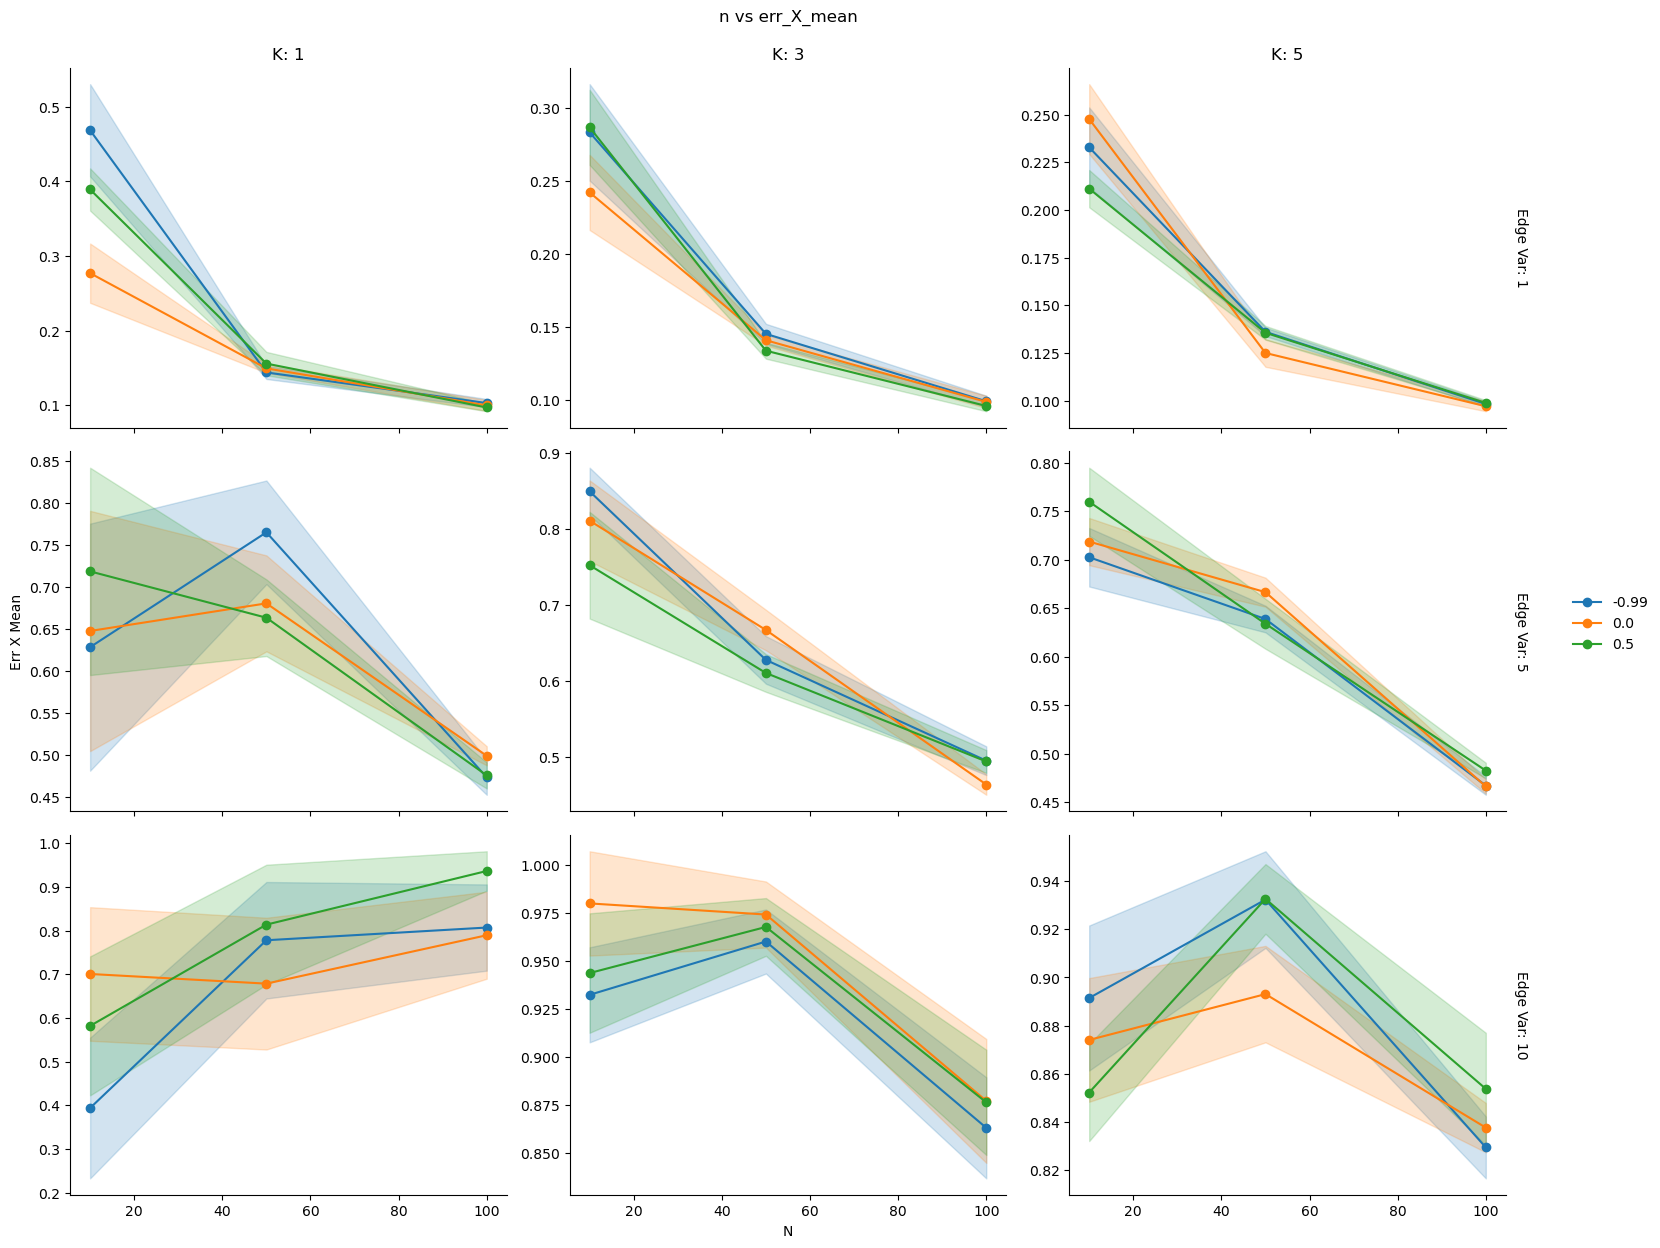

In [27]:
plot_grid(
        grouped_stats=agg_out_X,
        plotting_function=plot_with_bands,
        x_axis='n',
        y_axis='err_X_mean',
        factors=['sigma', 'k', 'edge_var'],
        height=4,
        se_bands='err_X_sem',
        share_x=True,
        share_y=False
    )

**Check normalistion in mse computation**

#### Independence test

In [45]:
rng = np.random.default_rng(1)
n = 100
k = 5
edge_var = 1
sigma = 0

A, B, Z, X = generate_gaussian_data(n, k, sigma, edge_var=edge_var, rng=rng)

Zhat, evals_A = solve_independent(A, k=k)
Xhat, evals_B = solve_independent(B, k=k)
Zhat = Zhat[0]
Xhat = Xhat[0]

rv_est = rv_coefficient(Zhat, Xhat)
rv_coefficient(A, B), rv_coefficient(Zhat, Xhat), rv_coefficient(Z, X)

(np.float64(0.04022681435525203),
 np.float64(0.04085038334567111),
 np.float64(0.03974446543012147))

In [46]:
n_perm = 500
rv_distr = []
for i in range(n_perm):
    perm = rng.permutation(n)
    X_perm = X[perm, :]
    rv_perm = rv_coefficient(X_perm, Z)
    rv_distr.append(rv_perm)

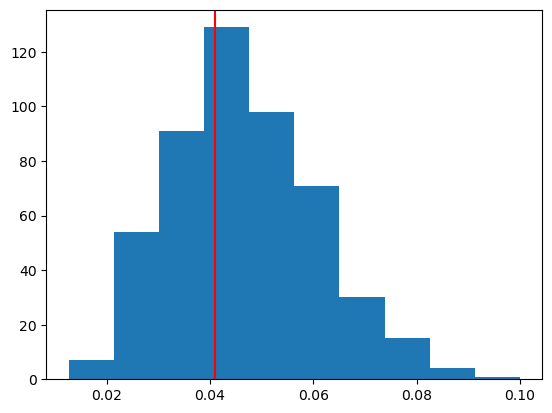

In [47]:
fig, ax = plt.subplots()
ax.hist(rv_distr)
ax.axvline(rv_est, color='red')
plt.show()